# 타이타닉 40 — 탐색적 데이터 분석 (EDA)

> **대상**: ML 입문(30~33)을 마친 단계. 첫 실전 프로젝트의 시작.
> **목표**: 모델을 만들기 전에 **데이터를 이해하는** EDA(Exploratory Data Analysis) — 결측치 파악, 생존에 영향을 주는 변수 탐색 — 를 수행하기.

지금까지는 붓꽃·와인처럼 **깨끗하게 정리된** 데이터를 썼습니다. 타이타닉은 **결측치가 있고 글자(범주형)가 섞인 진짜 데이터**예요. 모델을 바로 돌리기 전에, **"어떤 데이터인지, 무엇이 생존을 가르는지"를 먼저 탐색**합니다. 이 EDA가 다음 단계(41 전처리)의 방향을 정합니다.

> **데이터 준비**: 이 프로젝트는 Kaggle 타이타닉 대회 데이터를 씁니다. 처음 한 번 받아주세요 (재배포 규정상 repo엔 포함 안 함):
> ```bash
> kaggle competitions download -c titanic -p data/titanic
> # 받은 titanic.zip의 압축을 data/titanic/ 에 풀면 train.csv / test.csv 생성
> ```

## 0) 데이터 불러오기

```python
import pandas as pd
from pathlib import Path

# 데이터 폴더 — 노트북(notebooks/titanic/)에서 두 단계 위 루트의 data/titanic/
# Path의 / 연산자는 OS(Windows/Mac)에 무관하게 경로를 만들어 줌
DATA_DIR = Path.cwd().parent.parent / "data" / "titanic"

train = pd.read_csv(DATA_DIR / "train.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

train.shape    # (891, 12)  — 891명, 12개 열
test.shape     # (418, 11)  — test엔 Survived가 없음 (이걸 맞히는 게 목표)
```

> 경로를 문자열(`"../../data/..."`)로 직접 쓰면 노트북 실행 위치·OS에 따라 깨지기 쉽습니다. `pathlib.Path`로 `DATA_DIR`를 한 번 정의해두고 `DATA_DIR / "train.csv"`처럼 재사용하면 견고합니다.

> **train/test 구조**: train은 정답(`Survived`)이 있는 891명, test는 정답이 없는 418명입니다. train으로 배워서 test의 생존 여부를 예측하는 게 캐글 대회의 목표예요. (30에서 배운 train/test 분할이 **데이터셋 자체로** 주어진 셈)

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "titanic"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape

(891, 12)

In [2]:
test.shape

(418, 11)

## 1) 첫인상 — head / info / describe

```python
train.head()         # 앞 5행 — 어떤 열이 있나
train.info()         # 열별 타입과 결측치(non-null 개수)
train.describe()     # 수치형 열의 통계(평균·최대·사분위 등)
```

**주요 열의 의미:**

| 열 | 의미 | 타입 |
|----|------|------|
| `Survived` | 생존 여부 (0=사망, 1=생존) — **정답** | 수치(0/1) |
| `Pclass` | 객실 등급 (1·2·3) | 수치(범주적) |
| `Sex` | 성별 | 범주(글자) |
| `Age` | 나이 | 수치 |
| `SibSp` / `Parch` | 형제·배우자 수 / 부모·자녀 수 | 수치 |
| `Fare` | 운임 | 수치 |
| `Embarked` | 승선 항구 (C·Q·S) | 범주(글자) |
| `Cabin` | 객실 번호 | 범주(결측 많음) |

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2) 결측치 확인 (전처리의 출발점)

```python
train.isna().sum()
```

**결과:**

```
Age          177    — 약 20%가 비어 있음 → 채워야 함(41에서)
Cabin        687    — 약 77%가 비어 있음 → 너무 많아 보통 버림
Embarked       2    — 2개만 → 최빈값으로 채우면 됨
(나머지는 결측 없음)
```

> EDA의 첫 임무는 **"어디가 비었나"** 입니다. 모델은 빈 값을 못 먹어요(에러). `Age`는 채우고(median 등), `Cabin`은 결측이 77%라 보통 제거, `Embarked`는 2개뿐이라 최빈값으로 채웁니다. 이 판단이 41 전처리로 이어집니다.

In [6]:
train.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3) 무엇이 생존을 가르나 — 그룹별 생존율 (핵심)

`groupby`(21)로 "어떤 그룹이 더 살았나"를 봅니다.

```python
train["Survived"].mean()                      # 0.384  — 전체 생존율 38%

train.groupby("Sex")["Survived"].mean()
# female    0.742    ← 여성 74% 생존
# male      0.189    ← 남성 19% 생존  ("여성·아이 먼저")

train.groupby("Pclass")["Survived"].mean()
# 1    0.630    ← 1등급 63%
# 2    0.473
# 3    0.242    ← 3등급 24%  (등급이 낮을수록 덜 생존)
```

> **가장 강한 신호 두 개**: 성별(여성 74% vs 남성 19%)과 객실 등급(1등급 63% vs 3등급 24%). "여성·아이 먼저", "1등급 우선 대피"라는 역사적 사실이 데이터에 그대로 보입니다. 이 변수들이 **모델의 핵심 특성**이 될 거예요.

**두 변수를 교차로 보면 더 선명합니다:**

```python
train.groupby(["Sex", "Pclass"])["Survived"].mean()
# female  1    0.968    ← 1등급 여성 97% 생존
# female  3    0.500
# male    1    0.369
# male    3    0.135    ← 3등급 남성 14% 생존
```

> 1등급 여성 **97%** vs 3등급 남성 **14%** — 같은 배에서 생존율이 7배 차이. 성별·등급이 생존을 강하게 가른다는 걸 한눈에 보여줍니다.

In [10]:
train["Survived"].mean()

np.float64(0.3838383838383838)

In [11]:
train.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [12]:
train.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [14]:
import pandas as pd
pd.DataFrame(train.groupby(["Sex", "Pclass"])["Survived"].mean())

Survived
Sex    Pclass          
female 1       0.968085
       2       0.921053
       3       0.500000
male   1       0.368852
       2       0.157407
       3       0.135447

## 4) 시각화로 확인 (22 활용)

숫자로 본 패턴을 그림으로 확인합니다. (22의 한글 폰트 설정을 먼저 실행)

```python
import matplotlib.pyplot as plt
import seaborn as sns

# 성별 생존율
sns.barplot(data=train, x="Sex", y="Survived")
plt.title("성별 생존율")
plt.show()

# 등급별 생존율
sns.barplot(data=train, x="Pclass", y="Survived")
plt.show()

# 나이 분포 (생존/사망 비교)
sns.histplot(data=train, x="Age", hue="Survived", bins=30)
plt.show()
```

> `barplot`은 그룹별 평균을 자동 계산하므로 **생존율 막대**가 바로 그려집니다(22에서 본 것). `hue="Survived"`로 생존/사망을 색으로 나눠 분포를 겹쳐 봅니다. 나이는 성별·등급만큼 강하진 않지만(생존자 평균 28.3 vs 사망자 30.6), 어린이 쪽이 약간 더 생존하는 경향이 보입니다.

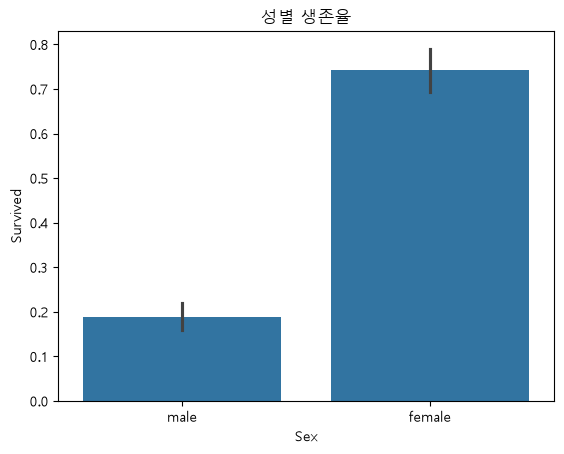

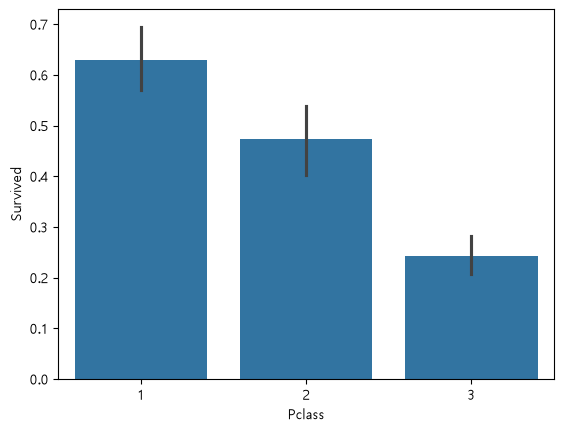

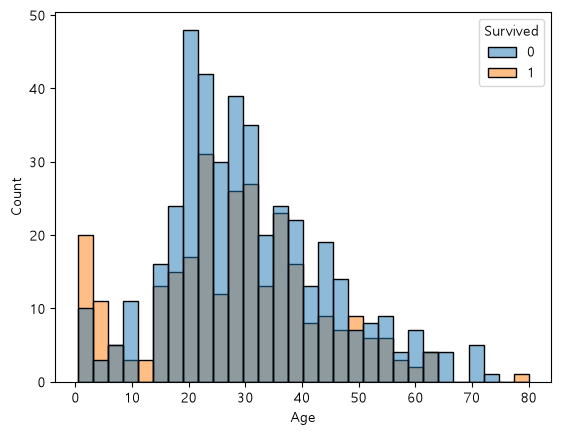

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import platform

system = platform.system()
if system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

sns.barplot(data=train, x="Sex", y="Survived")
plt.title("성별 생존율")
plt.show()

sns.barplot(data=train, x="Pclass", y="Survived")
plt.show()

sns.histplot(data=train, x="Age", hue="Survived", bins=30)
plt.show()

## 대표 예제 — 생존율 요약표

> 성별·등급별 생존율을 한 표로 정리하라. (pandas `groupby` + `unstack`로 교차표)

```python
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "titanic"
train = pd.read_csv(DATA_DIR / "train.csv")

# 성별 × 등급 교차 생존율 표
summary = train.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().round(3)
print(summary)
```

**기대 결과:**

```
Pclass       1      2      3
Sex
female   0.968  0.921  0.500
male     0.369  0.157  0.135
```

> 가르칠 포인트: `unstack()`이 `Pclass`를 열로 펼쳐 **교차표**를 만듭니다(엑셀 피벗테이블 같은). 한 표로 "여성일수록·고등급일수록 생존율이 높다"가 명확히 보입니다. **EDA의 결론 = 다음 단계에서 쓸 핵심 특성: Sex, Pclass.** (나이·운임·승선항·가족 수도 보조로)

In [19]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "titanic"
train = pd.read_csv(DATA_DIR / "train.csv")

summary = train.groupby(["Sex", "Pclass"])["Survived"].mean().unstack().round(3)
pd.DataFrame(summary)

Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


## 검증 (노트북에서 실행)

```python
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "titanic"
train = pd.read_csv(DATA_DIR / "train.csv")

# 전체 생존율 ≈ 0.384
assert abs(train["Survived"].mean() - 0.3838) < 0.001

# 성별 생존율
sex_sr = train.groupby("Sex")["Survived"].mean()
assert abs(sex_sr["female"] - 0.742) < 0.001
assert abs(sex_sr["male"] - 0.189) < 0.001

# 결측치 개수
na = train.isna().sum()
assert na["Age"] == 177
assert na["Cabin"] == 687
assert na["Embarked"] == 2
print("통과 ✅")
```

In [20]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd().parent.parent / "data" / "titanic"
train = pd.read_csv(DATA_DIR / "train.csv")

# 전체 생존율 ≈ 0.384
assert abs(train["Survived"].mean() - 0.3838) < 0.001

# 성별 생존율
sex_sr = train.groupby("Sex")["Survived"].mean()
assert abs(sex_sr["female"] - 0.742) < 0.001
assert abs(sex_sr["male"] - 0.189) < 0.001

# 결측치 개수
na = train.isna().sum()
assert na["Age"] == 177
assert na["Cabin"] == 687
assert na["Embarked"] == 2
print("통과 ✅")

통과 ✅


## 직접 풀어보기 (연습)

`train`을 써서 `TODO`를 채운 뒤 검증 셀을 실행하세요. **"groupby로 생존율"**이 핵심 패턴입니다.

### 연습 1 — 승선항별 생존율

> 승선 항구(`Embarked`)별 생존율을 dict로 반환하라. (round 4자리)
> **힌트**: `groupby("Embarked")["Survived"].mean()`.

```python
def solution(train):
    # TODO: 승선항별 생존율 → round(4) → to_dict()
    pass

result = solution(train)
assert abs(result["C"] - 0.5536) < 0.001    # 셰르부르
assert abs(result["S"] - 0.337) < 0.001     # 사우샘프턴
print("통과 ✅")
```

### 연습 2 — 결측치가 있는 열 목록

> 결측치가 1개 이상 있는 열의 이름을 리스트로 반환하라.
> **힌트**: `train.isna().sum()`에서 0보다 큰 것의 인덱스.

```python
def solution(train):
    na = train.isna().sum()
    # TODO: na > 0 인 열 이름 리스트
    pass

assert set(solution(train)) == {"Age", "Cabin", "Embarked"}
print("통과 ✅")
```

### 연습 3 — 가족 수와 생존 (파생 변수, 도전)

> `SibSp + Parch + 1`로 `FamilySize`(본인 포함 가족 수)를 만들고, 가족 수별 생존율을 dict로 반환하라.
> **힌트**: 새 열 만들기(21) → `groupby("FamilySize")["Survived"].mean()`.

```python
def solution(train):
    df = train.copy()
    # TODO: FamilySize 열 만들고 가족수별 생존율 → round(4) → to_dict()
    pass

result = solution(train)
assert abs(result[1] - 0.3035) < 0.001    # 혼자 탄 사람 (생존율 낮음)
assert abs(result[4] - 0.7241) < 0.001    # 4인 가족 (생존율 높음)
print("통과 ✅")
```